# EDA of English Wikipedia

In [1]:
kaggle_env=False 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

if kaggle_env:
    import os
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            print(os.path.join(dirname, filename))

In [2]:
csv_path= '/kaggle/input/wikipedia-structured-contents/enwiki_namespace_0/' if kaggle_env else ''


In [3]:
#with pd.read_json('/kaggle/input/wikipedia-structured-contents/enwiki_namespace_0/enwiki_namespace_0_0.jsonl',lines=True,chunksize=100_000) as reader:
#    reader
#    for chunk in reader:
#        print(chunk)

In [6]:
wiki_json_df=(pd
              .read_json(csv_path+'enwiki_namespace_0_0.jsonl',
                         lines=True,
                         nrows=50_000,
                         convert_dates=['date_created','date_modified'])
             )

In [7]:
wiki_json_df

,name,identifier,version,event,url,date_created,date_modified,is_part_of,in_language,license,description,sections,abstract,main_entity,additional_entities,infoboxes,image
0,Not Again SU,76716259,"{'identifier': 1220413474, 'comment': 'Added #...",{'identifier': 'fa3cae5b-8707-4f55-9fab-5baa4c...,https://en.wikipedia.org/wiki/Not_Again_SU,2024-04-23 16:50:32+00:00,2024-04-23 16:53:55+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,"Student organization in Syracuse, New York","[{'type': 'section', 'name': 'Abstract'}, {'ty...",NaN,NaN,NaN,NaN,NaN
1,Mike Ross (Suits),76727681,"{'identifier': 1220574416, 'comment': 'Request...",{'identifier': '22366970-ddf7-43dc-8cec-941de1...,https://en.wikipedia.org/wiki/Mike_Ross_(Suits),2024-04-24 17:12:05+00:00,2024-04-24 17:14:10+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,An American Legal drama series from 2011-2019,"[{'type': 'section', 'name': 'Abstract', 'has_...",REDIRECT List of Suits characters#Mike Ross,"{'identifier': 'Q125388612', 'url': 'https://w...","[{'identifier': 'Q125388612', 'url': 'https://...",NaN,NaN
2,Second Polish republic,76744378,"{'identifier': 1220875620, 'comment': '[[WP:AE...",{'identifier': '552624d6-5c55-45ef-a8e3-945335...,https://en.wikipedia.org/wiki/Second_Polish_re...,2024-04-26 13:30:10+00:00,2024-04-26 13:30:10+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,Country in Central and Eastern Europe (1918–1939),"[{'type': 'section', 'name': 'Abstract', 'has_...",REDIRECT #Second Polish Republic,NaN,NaN,NaN,NaN
3,Left-to-right script,76735997,"{'identifier': 1220716997, 'comment': 'create ...",{'identifier': 'aae6c4ee-bf95-4dc0-942d-5eea53...,https://en.wikipedia.org/wiki/Left-to-right_sc...,2024-04-25 13:58:39+00:00,2024-04-25 13:58:39+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,Convention of symbols representing language,"[{'type': 'section', 'name': 'Abstract', 'has_...",REDIRECT Writing system#Directionality,NaN,NaN,NaN,NaN
4,1442 in France,58128987,"{'identifier': 1145356533, 'comment': 'Alter: ...",{'identifier': 'c4526432-0a4a-42ed-8ef7-54827c...,https://en.wikipedia.org/wiki/1442_in_France,NaT,2023-03-18 18:38:51+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,List of events in the year 1442,"[{'type': 'section', 'name': 'Abstract', 'has_...",Events from the year 1442 in France,"{'identifier': 'Q56292328', 'url': 'https://ww...","[{'identifier': 'Q56292328', 'url': 'https://w...","[{'type': 'infobox', 'name': 'Year in France h...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Bedlington Terriers F.C.,3728451,"{'identifier': 1178198200, 'comment': 'Rescuin...",{'identifier': 'f3a519d2-8f55-4f37-82d4-7303a8...,https://en.wikipedia.org/wiki/Bedlington_Terri...,NaT,2023-10-02 04:23:05+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,Association football club in England,"[{'type': 'section', 'name': 'Abstract', 'has_...",Bedlington Terriers Football Club is a footbal...,"{'identifier': 'Q4879300', 'url': 'https://www...","[{'identifier': 'Q26953040', 'url': 'https://w...","[{'type': 'infobox', 'name': 'Infobox football...",NaN
49996,Bataysk Museum of History,57863898,"{'identifier': 1162859193, 'comment': 'Removin...",{'identifier': '138bf9c6-7e04-4a27-bc44-23d756...,https://en.wikipedia.org/wiki/Bataysk_Museum_o...,NaT,2023-07-01 14:17:40+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,NaN,"[{'type': 'section', 'name': 'Abstract', 'has_...",The Bataysk Mus

## Date created

<Axes: xlabel='date_created'>

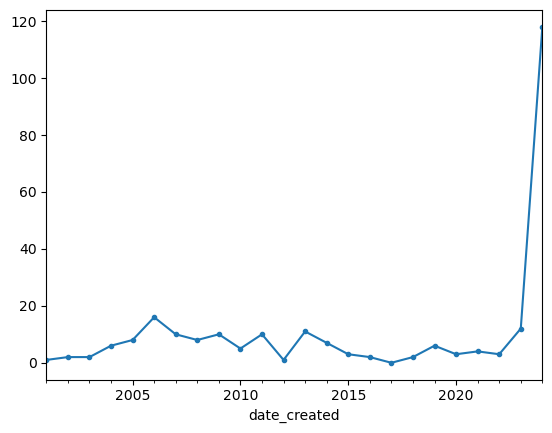

In [8]:
(wiki_json_df
 .set_index('date_created')
 .resample('1YE')
 .count()
 ['date_modified']
 .plot(marker='.')
)

## Names

<Axes: ylabel='name'>

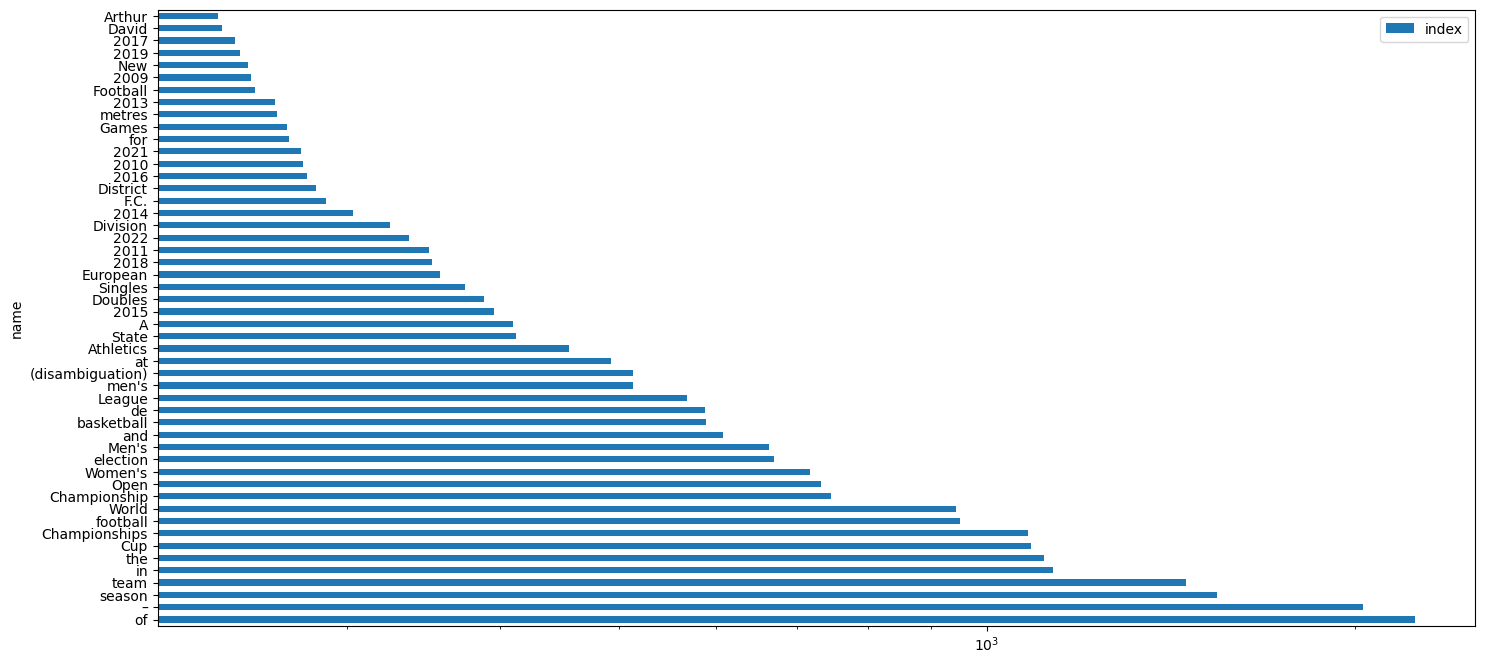

In [9]:
(wiki_json_df
 .name
 .str
 .split()
 .explode('name')
 .dropna()
 .reset_index()
 .groupby('name')
 .count()
 .sort_values('index',ascending=False)
 .iloc[0:50]
 .plot(kind='barh',logx=True,figsize=[17,8])

)

## Descriptions

<Axes: ylabel='description'>

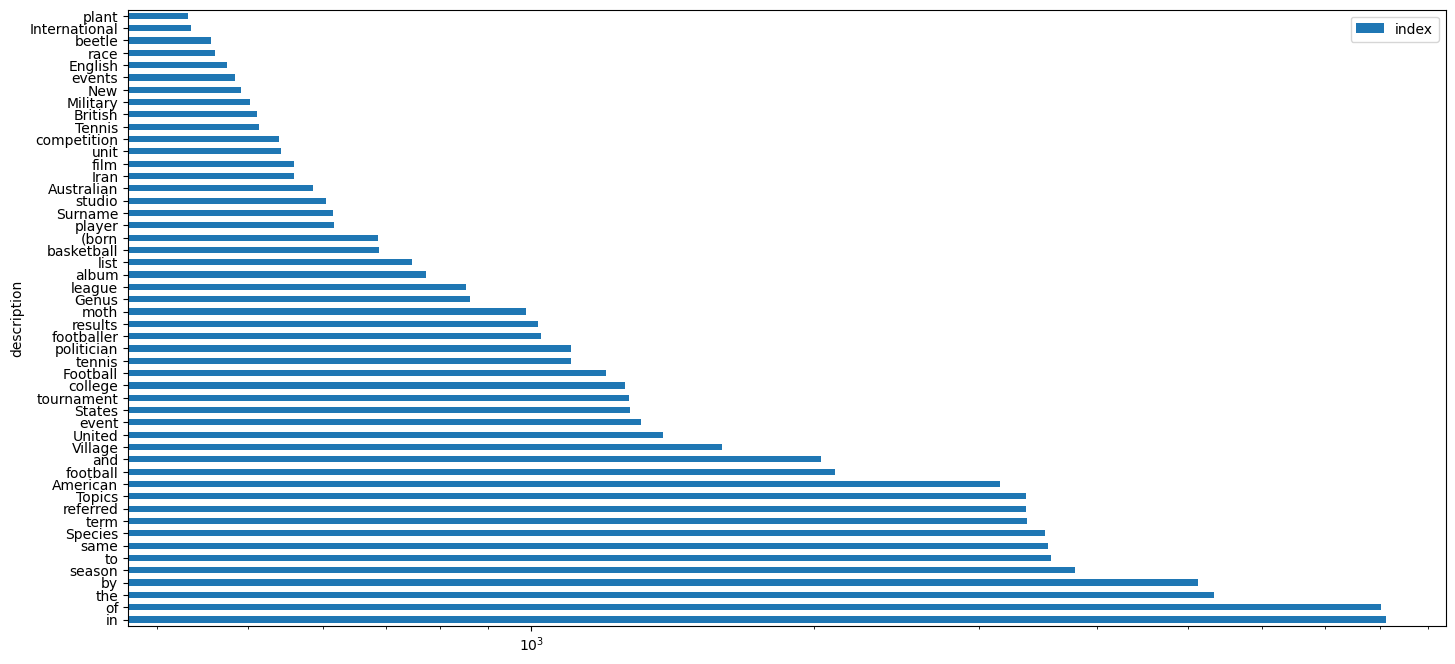

In [10]:
(wiki_json_df
 .description
 .str
 .split()
 .explode('description')
 .dropna()
 .reset_index()
 .groupby('description')
 .count()
 .sort_values('index',ascending=False)
 .iloc[0:50]
 .plot(kind='barh',logx=True,figsize=[17,8])

)

<Axes: ylabel='Frequency'>

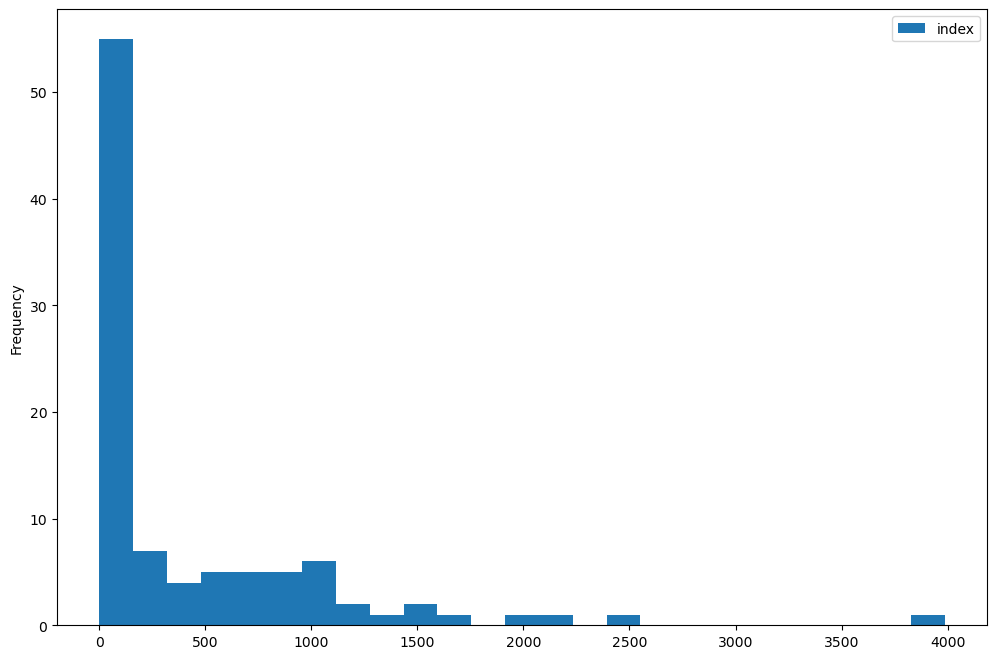

In [11]:
(wiki_json_df
 .description
 .str
 .len()
 .reset_index()
 .groupby('description')
 .count()
 .sort_values('description',ascending=False)
 .plot(kind='hist',figsize=[12,8],bins=25)
)

In [12]:
(wiki_json_df
 .description
 .str
 .len()
 .reset_index()
 .groupby('description')
 .count()
 .mean()
)

index    422.43299
dtype: float64

## abstracts

<Axes: ylabel='abstract'>

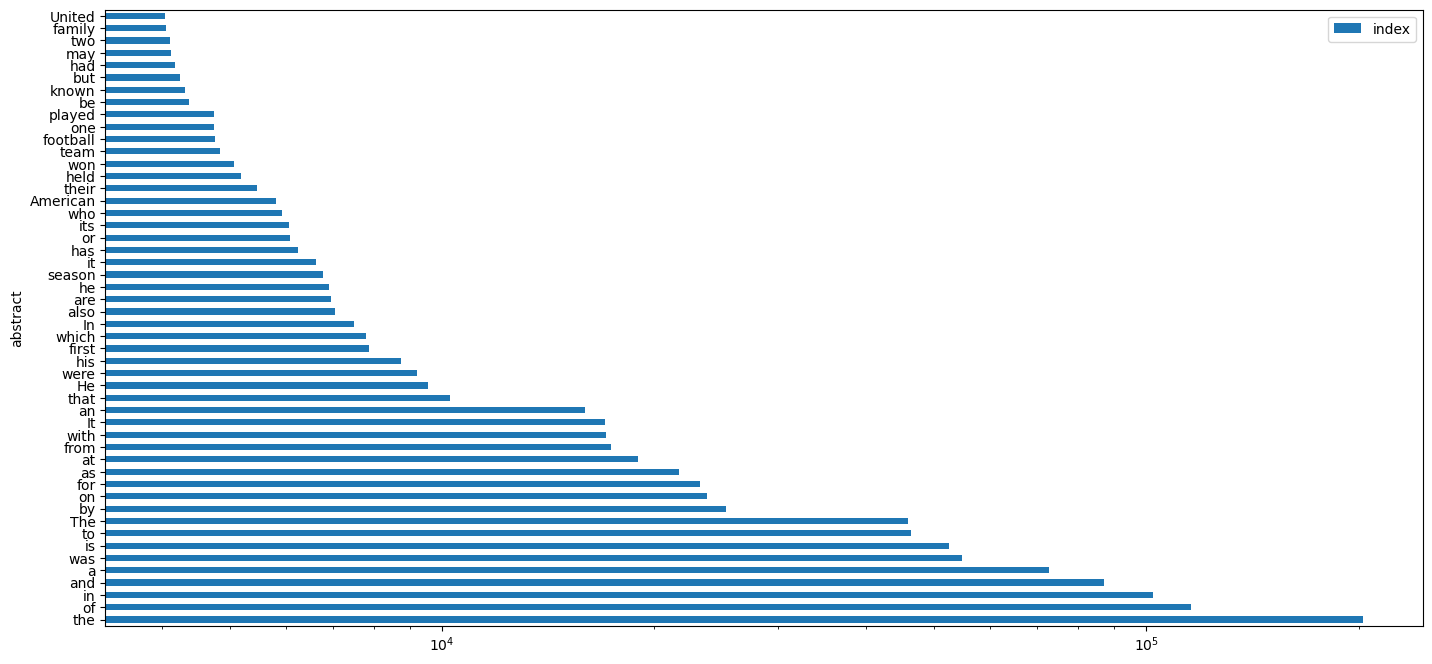

In [13]:
(wiki_json_df
 .abstract
 .str
 .split()
 .explode('abstract')
 .dropna()
 .reset_index()
 .groupby('abstract')
 .count()
 .sort_values('index',ascending=False)
 .iloc[0:50]
 .plot(kind='barh',logx=True,figsize=[17,8])

)

<Axes: xlabel='abstract'>

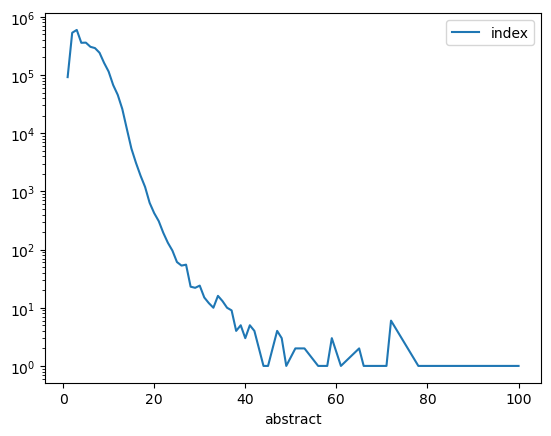

In [14]:
(wiki_json_df
 .abstract
 .str
 .split()
 .explode('abstract')
 .dropna()
 .str
 .len()
 .reset_index()
 .groupby('abstract')
 .count()
 .plot(logy=True)

)

## Section Names

In [15]:
wiki_json_df.explode('sections',ignore_index=True)

,name,identifier,version,event,url,date_created,date_modified,is_part_of,in_language,license,description,sections,abstract,main_entity,additional_entities,infoboxes,image
0,Not Again SU,76716259,"{'identifier': 1220413474, 'comment': 'Added #...",{'identifier': 'fa3cae5b-8707-4f55-9fab-5baa4c...,https://en.wikipedia.org/wiki/Not_Again_SU,2024-04-23 16:50:32+00:00,2024-04-23 16:53:55+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,"Student organization in Syracuse, New York","{'type': 'section', 'name': 'Abstract'}",NaN,NaN,NaN,NaN,NaN
1,Not Again SU,76716259,"{'identifier': 1220413474, 'comment': 'Added #...",{'identifier': 'fa3cae5b-8707-4f55-9fab-5baa4c...,https://en.wikipedia.org/wiki/Not_Again_SU,2024-04-23 16:50:32+00:00,2024-04-23 16:53:55+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,"Student organization in Syracuse, New York","{'type': 'section', 'name': 'Introduction:', '...",NaN,NaN,NaN,NaN,NaN
2,Not Again SU,76716259,"{'identifier': 1220413474, 'comment': 'Added #...",{'identifier': 'fa3cae5b-8707-4f55-9fab-5baa4c...,https://en.wikipedia.org/wiki/Not_Again_SU,2024-04-23 16:50:32+00:00,2024-04-23 16:53:55+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,"Student organization in Syracuse, New York","{'type': 'section', 'name': 'Demands:', 'has_p...",NaN,NaN,NaN,NaN,NaN
3,Mike Ross (Suits),76727681,"{'identifier': 1220574416, 'comment': 'Request...",{'identifier': '22366970-ddf7-43dc-8cec-941de1...,https://en.wikipedia.org/wiki/Mike_Ross_(Suits),2024-04-24 17:12:05+00:00,2024-04-24 17:14:10+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,An American Legal drama series from 2011-2019,"{'type': 'section', 'name': 'Abstract', 'has_p...",REDIRECT List of Suits characters#Mike Ross,"{'identifier': 'Q125388612', 'url': 'https://w...","[{'identifier': 'Q125388612', 'url': 'https://...",NaN,NaN
4,Second Polish republic,76744378,"{'identifier': 1220875620, 'comment': '[[WP:AE...",{'identifier': '552624d6-5c55-45ef-a8e3-945335...,https://en.wikipedia.org/wiki/Second_Polish_re...,2024-04-26 13:30:10+00:00,2024-04-26 13:30:10+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,Country in Central and Eastern Europe (1918–1939),"{'type': 'section', 'name': 'Abstract', 'has_p...",REDIRECT #Second Polish Republic,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129139,Gene Abrams,61405069,"{'identifier': 1201104647, 'tags': ['wikiedito...",{'identifier': '7c72ca70-3ef6-40cc-9e81-e3465e...,https://en.wikipedia.org/wiki/Gene_Abrams,NaT,2024-01-30 23:06:32+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,American mathematician,"{'type': 'section', 'name': 'Abstract', 'has_p...",Gene Abrams is an American mathematician and P...,"{'identifier': 'Q66013641', 'url': 'https://ww...","[{'identifier': 'Q66013641', 'url': 'https://w...","[{'type': 'infobox', 'name': 'Infobox scientis...",NaN
129140,Gene Abrams,61405069,"{'identifier': 1201104647, 'tags': ['wikiedito...",{'identifier': '7c72ca70-3ef6-40cc-9e81-e3465e...,https://en.wikipedia.org/wiki/Gene_Abrams,NaT,2024-01-30 23:06:32+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,American mathematician,"{'type': 'section', 'name': 'Leavitt path alge...",Gene Abrams is an American mathematician and P...,"{'identifier': 'Q66013641', 'url': 'https://ww...","[{'identifier': 'Q66013641', 'url': 'https://w...","[{'type': 'infobox', 'name': 'Infobox scientis...",NaN
129141,Gene Abrams,61405069,"{'identifier': 

In [21]:
wiki_json_df.explode('sections').iloc[2982]

name                                                               18 km
identifier                                                      58095060
version                {'identifier': 1057462691, 'comment': 'Removed...
event                  {'identifier': '5f1f131e-e206-4dbf-9d1f-912ee1...
url                                  https://en.wikipedia.org/wiki/18_km
date_created                                                         NaT
date_modified                                  2021-11-27 20:03:52+00:00
is_part_of             {'identifier': 'enwiki', 'url': 'https://en.wi...
in_language                                         {'identifier': 'en'}
license                [{'name': 'Creative Commons Attribution-ShareA...
description                         Settlement in Vologda Oblast, Russia
sections               {'type': 'section', 'name': 'Geography', 'has_...
abstract               18 km is a rural locality in Vokhtozhskoye Urb...
main_entity            {'identifier': 'Q4029391', '

In [22]:
for wiki_entry in wiki_json_df.explode('sections').iloc[2982]:
    print(wiki_entry)

18 km
58095060
{'identifier': 1057462691, 'comment': 'Removed the dead link', 'editor': {'identifier': 40524602, 'name': 'Pawpawz'}, 'number_of_characters': 2173, 'size': {'value': 2295, 'unit_text': 'B'}}
{'identifier': '5f1f131e-e206-4dbf-9d1f-912ee1ae1df2', 'type': 'update', 'date_created': '2024-04-27T00:36:10.242514Z', 'date_published': '2024-08-06T08:45:42.852808Z'}
https://en.wikipedia.org/wiki/18_km
NaT
2021-11-27 20:03:52+00:00
{'identifier': 'enwiki', 'url': 'https://en.wikipedia.org'}
{'identifier': 'en'}
[{'name': 'Creative Commons Attribution-ShareAlike 4.0', 'identifier': 'CC-BY-SA-4.0', 'url': 'https://creativecommons.org/licenses/by-sa/4.0/'}]
Settlement in Vologda Oblast, Russia
{'type': 'section', 'name': 'Geography', 'has_parts': [{'type': 'paragraph', 'value': "The settlement is located on the bank of the Monza River, 79 km east of Gryazovets (the district's administrative centre) by road. Monza is the nearest rural locality.", 'links': [{'url': 'https://en.wikipedi

<Axes: ylabel='sections'>

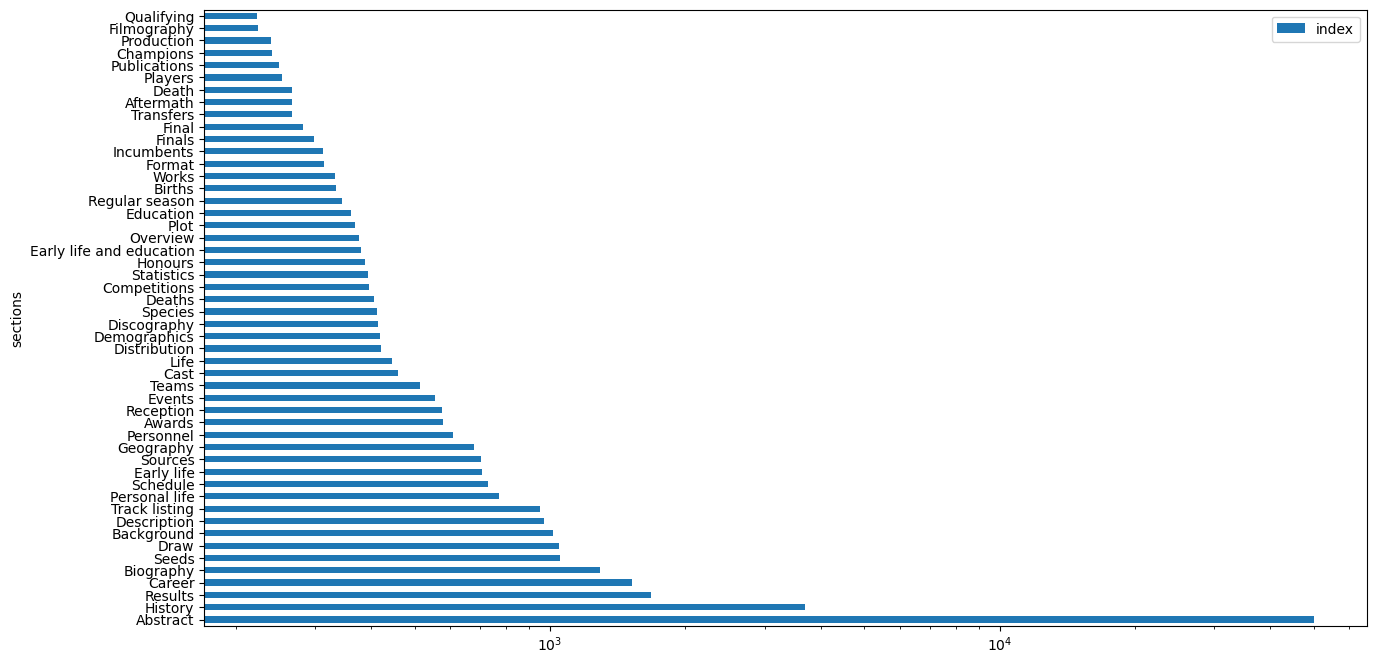

In [18]:
(wiki_json_df
 .explode('sections',ignore_index=True)
 .sections
 .dropna()
 .apply(lambda x:  x['name'] if 'name' in x else None)#.groupby('sections').count()
 .dropna()
 .reset_index()
 .groupby('sections')
 .count()
 .sort_values('index',ascending=False)
 .iloc[0:50]
 .plot(kind='barh',logx=True,figsize=[15,8])

)

In [19]:
(wiki_json_df
 .explode('sections',ignore_index=True)
 .assign(
     section_name= wiki_json_df.explode('sections',ignore_index=True).sections.dropna().apply(lambda x:  x['name'] if 'name' in x else None)#.groupby('sections').count()
)
.query("section_name=='Geography'")

)

,name,identifier,version,event,url,date_created,date_modified,is_part_of,in_language,license,description,sections,abstract,main_entity,additional_entities,infoboxes,image,section_name
2982,18 km,58095060,"{'identifier': 1057462691, 'comment': 'Removed...",{'identifier': '5f1f131e-e206-4dbf-9d1f-912ee1...,https://en.wikipedia.org/wiki/18_km,NaT,2021-11-27 20:03:52+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,"Settlement in Vologda Oblast, Russia","{'type': 'section', 'name': 'Geography', 'has_...",18 km is a rural locality in Vokhtozhskoye Urb...,"{'identifier': 'Q4029391', 'url': 'https://www...","[{'identifier': 'Q4029391', 'url': 'https://ww...","[{'type': 'infobox', 'name': 'Infobox settleme...",NaN,Geography
3184,1214 km,58109067,"{'identifier': 944490071, 'comment': '/* Refer...",{'identifier': 'de222c83-aadc-4669-a938-e3551c...,https://en.wikipedia.org/wiki/1214_km,NaT,2020-03-08 04:31:00+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,"Village in Udmurtia, Russia","{'type': 'section', 'name': 'Geography', 'has_...",1214 km is a rural locality in Voyegurtskoye R...,"{'identifier': 'Q4028574', 'url': 'https://www...","[{'identifier': 'Q4028574', 'url': 'https://ww...","[{'type': 'infobox', 'name': 'Infobox settleme...",NaN,Geography
3329,"Lafayette, Louisiana metropolitan area",76718236,"{'identifier': 1220456467, 'tags': ['wikiedito...",{'identifier': '5b81841e-e4aa-4b73-986e-1bc130...,"https://en.wikipedia.org/wiki/Lafayette,_Louis...",2024-04-23 19:50:32+00:00,2024-04-23 21:50:02+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,"Metropolitan statistical area in Louisiana, Un...","{'type': 'section', 'name': 'Geography', 'has_...","Lafayette, Vermilionville, or the Lafayette me...",NaN,NaN,"[{'type': 'infobox', 'name': 'Infobox settleme...",{'content_url': 'https://upload.wikimedia.org/...,Geography
3338,Memmingen – Unterallgäu,76746288,"{'identifier': 1220938604, 'tags': ['wikiedito...",{'identifier': '4eee9f31-d9ed-48d0-90b1-98ecd6...,https://en.wikipedia.org/wiki/Memmingen_%E2%80...,2024-04-26 17:07:31+00:00,2024-04-26 21:13:16+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,Federal electoral district of Germany,"{'type': 'section', 'name': 'Geography', 'has_...",Memmingen – Unterallgäu is an electoral consti...,NaN,NaN,"[{'type': 'infobox', 'name': 'Infobox constitu...",{'content_url': 'https://upload.wikimedia.org/...,Geography
10627,Affeln,18428150,"{'identifier': 1068279545, 'comment': '/* top ...",{'identifier': '0d6c7546-6d84-474d-882c-4beb06...,https://en.wikipedia.org/wiki/Affeln,NaT,2022-01-27 15:29:31+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,Ortsteil of Neuenrade in North Rhine-Westphali...,"{'type': 'section', 'name': 'Geography', 'has_...","Affeln is a German village in Neuenrade, a mun...","{'identifier': 'Q382268', 'url': 'https://www....","[{'identifier': 'Q382268', 'url': 'https://www...","[{'type': 'infobox', 'name': 'Infobox German l...",{'content_url': 'https://upload.wikimedia.org/...,Geography
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128902,Bolshoye Zaymishche,63240978,"{'identifier': 1052295196, 'editor': {'identif...",{'identifier': '6684bdcf-85c6-44a5-a61a-2d5ba5...,https://en.wikipedia.org/wiki/Bolshoye_Zaymishche,NaT,2021-10-28 11:30:12+00:00,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,"Village in Vologda Oblast, Russia","{'type': 'section', 'name': 'Geography', 'has_...",Bolshoye Zaymishche is a rural locality in Per...,"{'identifier': 'Q4092307', 'url': 'https://www...","

In [23]:
for list_item in wiki_json_df[wiki_json_df.identifier==58095060].infoboxes:
    print(list_item)

[{'type': 'infobox', 'name': 'Infobox settlement', 'has_parts': [{'type': 'section', 'name': '18 km 18 км'}, {'type': 'section', 'name': 'Settlement', 'has_parts': [{'type': 'field', 'value': '18 km 18 km', 'images': [{'content_url': 'https://upload.wikimedia.org/wikipedia/commons/thumb/7/79/Outline_Map_of_Vologda_Oblast.svg/250px-Outline_Map_of_Vologda_Oblast.svg.png', 'width': 250, 'height': 250, 'alternative_text': '18 km is located in Vologda Oblast'}, {'content_url': 'https://upload.wikimedia.org/wikipedia/commons/thumb/0/0c/Red_pog.svg/6px-Red_pog.svg.png', 'width': 6, 'height': 6, 'alternative_text': '18 km'}, {'content_url': 'https://upload.wikimedia.org/wikipedia/commons/thumb/e/e1/Russia_administrative_location_map.svg/250px-Russia_administrative_location_map.svg.png', 'width': 250, 'height': 250, 'alternative_text': '18 km is located in Russia'}, {'content_url': 'https://upload.wikimedia.org/wikipedia/commons/thumb/0/0c/Red_pog.svg/6px-Red_pog.svg.png', 'width': 6, 'height':